In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Upload kaggle.json API key
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'KGAT_6088906728b58938d46df095e001e52a'}

In [ ]:
import json
import os

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle/', exist_ok=True)

# ⚠️ Enter your Kaggle credentials before running
# Get your API key from: kaggle.com → Settings → API → Create New Token
KAGGLE_USERNAME = "YOUR_KAGGLE_USERNAME"
KAGGLE_KEY = "YOUR_KAGGLE_KEY"

kaggle_config = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

!chmod 600 /root/.kaggle/kaggle.json
print("Done!")

In [10]:
# Download dataset
!kaggle datasets download -d chethuhn/network-intrusion-dataset

# Unzip
!unzip -q network-intrusion-dataset.zip -d /content/cicids2017

# Check files
import os
print(os.listdir('/content/cicids2017'))

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:01<00:00, 169MB/s]

['Wednesday-workingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv']


In [11]:
import pandas as pd
import os

# Load all CSV files into one dataframe
path = '/content/cicids2017'
all_files = [f for f in os.listdir(path) if f.endswith('.csv')]

df_list = []
for file in all_files:
    df_list.append(pd.read_csv(os.path.join(path, file), low_memory=False))

df = pd.concat(df_list, ignore_index=True)

print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nFirst look:")
df.head()

Total rows: 2,830,743
Total columns: 79

First look:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [12]:
# Basic dataset information
print("=== Dataset Info ===")
print(f"Shape: {df.shape}")
print(f"\n=== Data Types ===")
print(df.dtypes.value_counts())
print(f"\n=== Target Variable Distribution ===")
print(df[' Label'].value_counts())
print(f"\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
Shape: (2830743, 79)

=== Data Types ===
int64      54
float64    24
object      1
Name: count, dtype: int64

=== Target Variable Distribution ===
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

=== Basic Statistics ===


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [13]:
import numpy as np

# Check missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print(missing[missing > 0])

# Check infinite values
print("\n=== Infinite Values ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(f"Total infinite values: {inf_count.sum()}")
print(inf_count[inf_count > 0])

# Check duplicate rows
print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum():,}")

=== Missing Values ===
Total missing values: 1358
Flow Bytes/s    1358
dtype: int64

=== Infinite Values ===
Total infinite values: 4376
Flow Bytes/s       1509
 Flow Packets/s    2867
dtype: int64

=== Duplicate Rows ===
Total duplicates: 308,381


In [14]:
# Step 1: Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]:,} rows")

# Step 2: Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Infinite values replaced with NaN")

# Step 3: Drop remaining NaN rows
df.dropna(inplace=True)
print(f"After removing NaN rows: {df.shape[0]:,} rows")

print(f"\nTotal rows removed: {2830743 - df.shape[0]:,}")
print(f"Remaining data: {df.shape[0]/2830743*100:.1f}%")

After removing duplicates: 2,522,362 rows
Infinite values replaced with NaN
After removing NaN rows: 2,520,798 rows

Total rows removed: 309,945
Remaining data: 89.1%


In [15]:
# Check label distribution after cleaning
print("=== Label Distribution After Cleaning ===")
label_counts = df[' Label'].value_counts()
label_pct = df[' Label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_pct.round(2)
})
print(summary)

=== Label Distribution After Cleaning ===
                              Count  Percentage
 Label                                         
BENIGN                      2095057       83.11
DoS Hulk                     172846        6.86
DDoS                         128014        5.08
PortScan                      90694        3.60
DoS GoldenEye                 10286        0.41
FTP-Patator                    5931        0.24
DoS slowloris                  5385        0.21
DoS Slowhttptest               5228        0.21
SSH-Patator                    3219        0.13
Bot                            1948        0.08
Web Attack � Brute Force       1470        0.06
Web Attack � XSS                652        0.03
Infiltration                     36        0.00
Web Attack � Sql Injection       21        0.00
Heartbleed                       11        0.00


/tmp/ipykernel_8258/3231765111.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[0], palette='Reds_r')


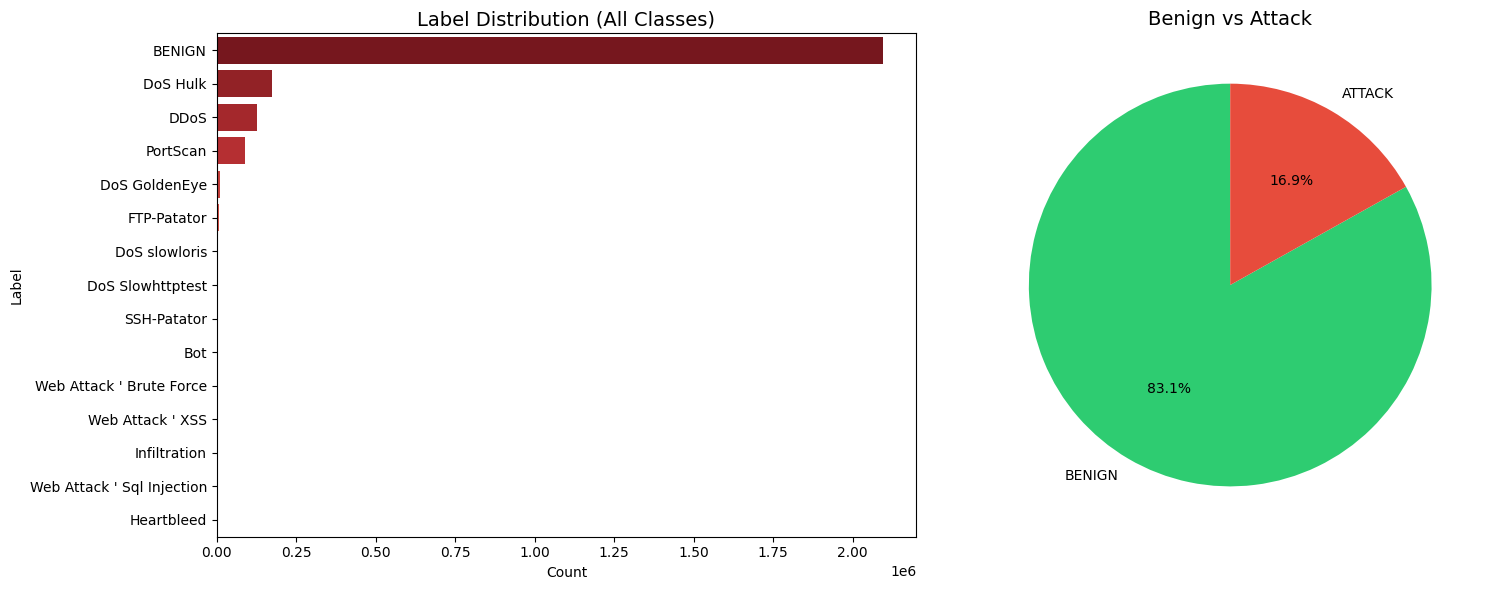

Plot saved!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean up label names (fix encoding issues)
df[' Label'] = df[' Label'].str.replace('�', "'")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All classes
label_counts = df[' Label'].value_counts()
sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Label Distribution (All Classes)', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Label')

# Plot 2: Binary (Benign vs Attack)
binary_counts = df[' Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK').value_counts()
axes[1].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Benign vs Attack', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [17]:
# Basic statistics per feature
print("=== Feature Statistics ===")
print(df.describe().T[['mean', 'std', 'min', 'max']].round(2))

=== Feature Statistics ===
                                    mean          std   min          max
 Destination Port                8690.59     19012.80   0.0      65535.0
 Flow Duration               16591611.46  35232762.93 -13.0  119999998.0
 Total Fwd Packets                 10.28       794.42   1.0     219759.0
 Total Backward Packets            11.57      1056.92   0.0     291922.0
Total Length of Fwd Packets       611.95     10588.27   0.0   12900000.0
...                                  ...          ...   ...          ...
 Active Min                     65463.59    611158.50   0.0  110000000.0
Idle Mean                     9337367.18  24848182.72   0.0  120000000.0
 Idle Std                      565794.14   4874168.99   0.0   76900000.0
 Idle Max                     9763770.48  25617458.42   0.0  120000000.0
 Idle Min                     8892670.65  24581432.88   0.0  120000000.0

[78 rows x 4 columns]


In [18]:
# Check labels of negative duration rows
print("=== Labels of Negative Duration Rows ===")
neg_duration = df[df[' Flow Duration'] < 0]
print(f"Total rows with negative duration: {len(neg_duration):,}")
print(f"\nLabel distribution:")
print(neg_duration[' Label'].value_counts())

=== Labels of Negative Duration Rows ===
Total rows with negative duration: 107

Label distribution:
 Label
BENIGN    107
Name: count, dtype: int64


In [19]:
# Remove negative Flow Duration rows
df = df[df[' Flow Duration'] >= 0]
print(f"Rows after removing negative duration: {df.shape[0]:,}")
print(f"Rows removed: 107")

Rows after removing negative duration: 2,520,691
Rows removed: 107


/tmp/ipykernel_8258/865729302.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pkt.values, y=avg_pkt.index, ax=axes[1,0], palette='viridis')
/tmp/ipykernel_8258/865729302.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby(' Label').apply(lambda x: x.sample(min(len(x), 500)))


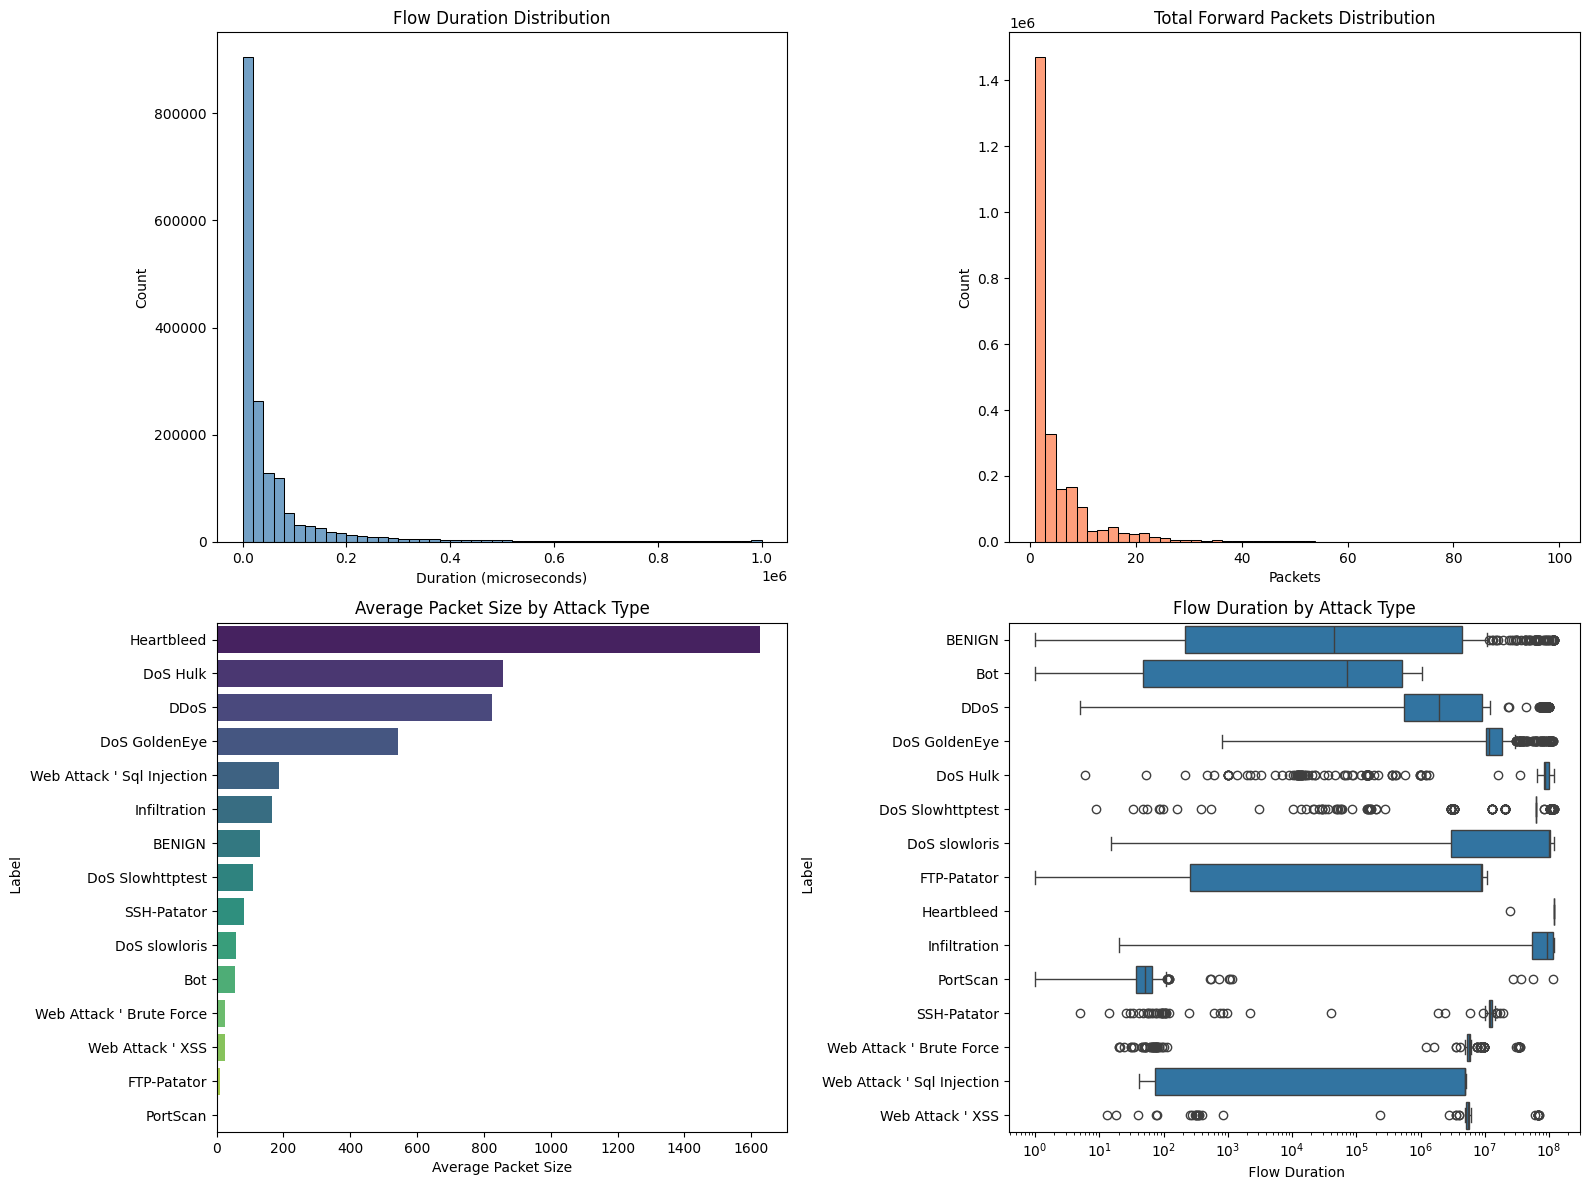

Plot saved!


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Flow Duration distribution
sns.histplot(df[df[' Flow Duration'] < 1000000][' Flow Duration'],
             bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Flow Duration Distribution')
axes[0,0].set_xlabel('Duration (microseconds)')

# Plot 2: Total Fwd Packets
sns.histplot(df[df[' Total Fwd Packets'] < 100][' Total Fwd Packets'],
             bins=50, ax=axes[0,1], color='coral')
axes[0,1].set_title('Total Forward Packets Distribution')
axes[0,1].set_xlabel('Packets')

# Plot 3: Average packet size by attack type
avg_pkt = df.groupby(' Label')[' Average Packet Size'].mean().sort_values(ascending=False)
sns.barplot(x=avg_pkt.values, y=avg_pkt.index, ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Average Packet Size by Attack Type')
axes[1,0].set_xlabel('Average Packet Size')

# Plot 4: Flow Duration by attack type
df_sample = df.groupby(' Label').apply(lambda x: x.sample(min(len(x), 500)))
sns.boxplot(data=df_sample, x=' Flow Duration', y=' Label', ax=axes[1,1])
axes[1,1].set_title('Flow Duration by Attack Type')
axes[1,1].set_xscale('log')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

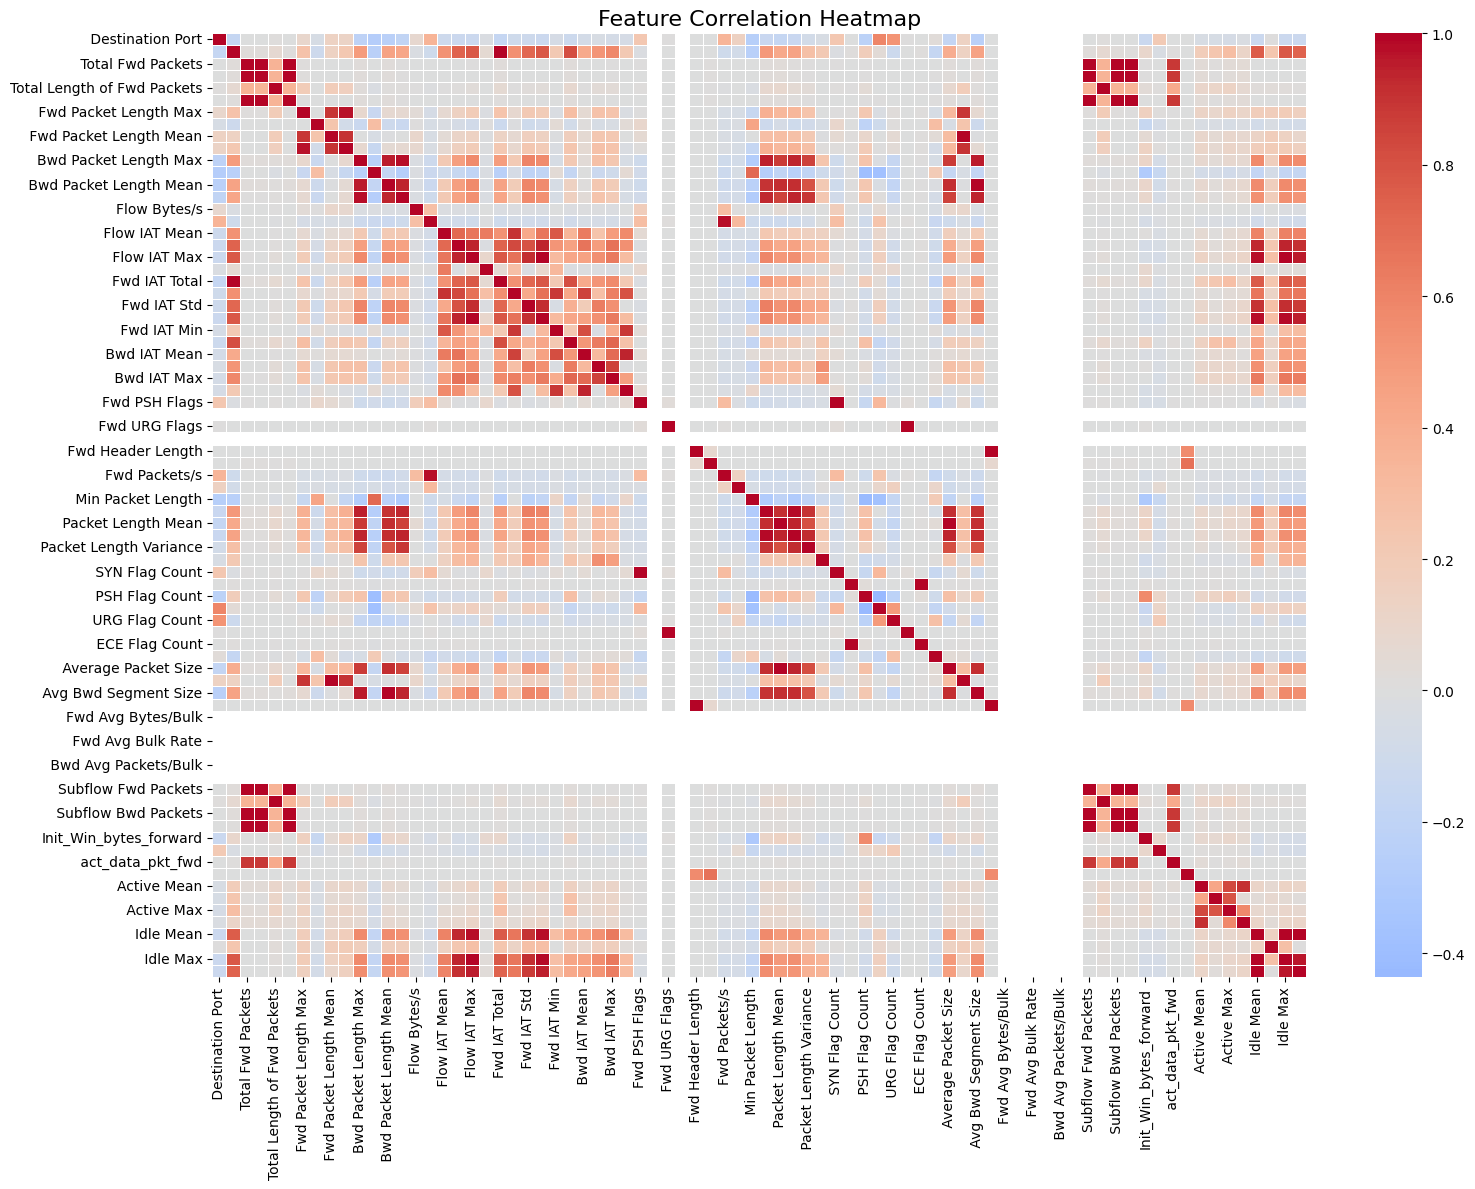

Done!


In [21]:
# Correlation heatmap of top features
plt.figure(figsize=(16, 12))

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            fmt='.1f',
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

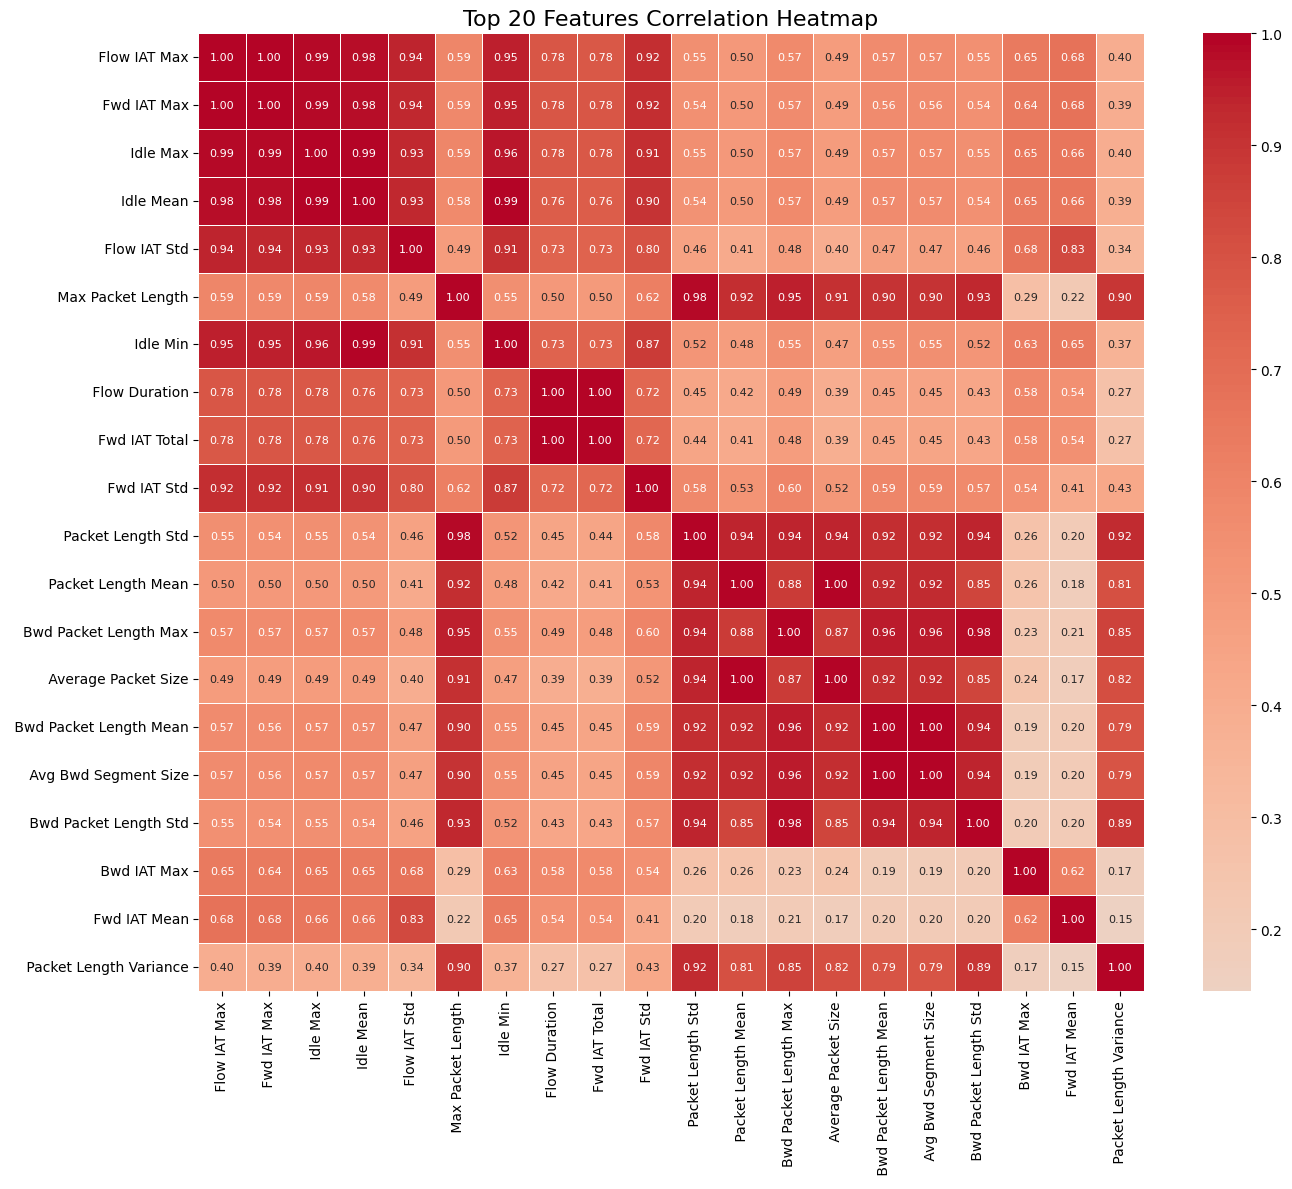

Done!


In [22]:
# Select top 20 most correlated features
plt.figure(figsize=(14, 12))

# Calculate correlation and select top 20
corr_matrix = numeric_df.corr()

# Find top 20 features with highest average correlation
top_features = corr_matrix.abs().mean().nlargest(20).index
corr_top = corr_matrix.loc[top_features, top_features]

# Plot heatmap
sns.heatmap(corr_top,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Top 20 Features Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [23]:
# Find highly correlated features (above 0.9)
corr_matrix = numeric_df.corr().abs()

# Get upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation above 0.9
highly_correlated = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

print(f"Highly correlated features (>0.9): {len(highly_correlated)}")
print("\nFeatures to consider removing:")
for col in highly_correlated:
    print(f"  - {col}")

Highly correlated features (>0.9): 31

Features to consider removing:
  -  Total Backward Packets
  -  Total Length of Bwd Packets
  -  Fwd Packet Length Std
  -  Bwd Packet Length Mean
  -  Bwd Packet Length Std
  -  Flow IAT Max
  - Fwd IAT Total
  -  Fwd IAT Mean
  -  Fwd IAT Std
  -  Fwd IAT Max
  -  Bwd IAT Min
  - Fwd Packets/s
  -  Max Packet Length
  -  Packet Length Mean
  -  Packet Length Std
  -  Packet Length Variance
  -  SYN Flag Count
  -  CWE Flag Count
  -  ECE Flag Count
  -  Average Packet Size
  -  Avg Fwd Segment Size
  -  Avg Bwd Segment Size
  -  Fwd Header Length.1
  - Subflow Fwd Packets
  -  Subflow Fwd Bytes
  -  Subflow Bwd Packets
  -  Subflow Bwd Bytes
  -  Active Min
  - Idle Mean
  -  Idle Max
  -  Idle Min


In [24]:
# Remove highly correlated features
df = df.drop(columns=highly_correlated)

print(f"Features before removal: 78")
print(f"Features removed: {len(highly_correlated)}")
print(f"Features remaining: {df.shape[1] - 1}")  # -1 for Label column
print(f"\nNew dataset shape: {df.shape}")

Features before removal: 78
Features removed: 31
Features remaining: 47

New dataset shape: (2520691, 48)


In [25]:
from sklearn.preprocessing import LabelEncoder

# Binary encoding (Benign=0, Attack=1)
df['Binary_Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Multi-class encoding
le = LabelEncoder()
df['Multi_Label'] = le.fit_transform(df[' Label'])

# Show mapping
print("=== Binary Label Encoding ===")
print("BENIGN = 0")
print("ATTACK = 1")
print(f"\nDistribution:")
print(df['Binary_Label'].value_counts())

print("\n=== Multi-class Label Encoding ===")
for i, label in enumerate(le.classes_):
    print(f"{i} = {label}")

=== Binary Label Encoding ===
BENIGN = 0
ATTACK = 1

Distribution:
Binary_Label
0    2094950
1     425741
Name: count, dtype: int64

=== Multi-class Label Encoding ===
0 = BENIGN
1 = Bot
2 = DDoS
3 = DoS GoldenEye
4 = DoS Hulk
5 = DoS Slowhttptest
6 = DoS slowloris
7 = FTP-Patator
8 = Heartbleed
9 = Infiltration
10 = PortScan
11 = SSH-Patator
12 = Web Attack ' Brute Force
13 = Web Attack ' Sql Injection
14 = Web Attack ' XSS


In [26]:
# Save cleaned dataset
df.to_csv('/content/cicids2017_cleaned.csv', index=False)
print(f"Dataset saved successfully!")
print(f"Shape: {df.shape}")
print(f"Size: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset saved successfully!
Shape: (2520691, 50)
Size: 1094.3 MB


In [27]:
print(df.shape)

(2520691, 50)


In [28]:
from sklearn.preprocessing import StandardScaler

# Separate features and labels
X = df.drop(columns=[' Label', 'Binary_Label', 'Multi_Label'])
y_binary = df['Binary_Label']
y_multi = df['Multi_Label']

print(f"Features shape: {X.shape}")
print(f"Binary labels shape: {y_binary.shape}")
print(f"Multi labels shape: {y_multi.shape}")

Features shape: (2520691, 47)
Binary labels shape: (2520691,)
Multi labels shape: (2520691,)


In [29]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train_binary, y_temp_binary, y_train_multi, y_temp_multi = train_test_split(
    X, y_binary, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_binary  # Keep class balance
)

# Second split: 50% validation, 50% test (from the 20%)
X_val, X_test, y_val_binary, y_test_binary, y_val_multi, y_test_multi = train_test_split(
    X_temp, y_temp_binary, y_temp_multi,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_binary
)

print(f"Train size:      {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation size: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test size:       {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

Train size:      2,016,552 (80.0%)
Validation size: 252,069 (10.0%)
Test size:       252,070 (10.0%)


In [30]:
# Apply StandardScaler - fit ONLY on train, transform all
scaler = StandardScaler()

# Fit on train only (learn the mean and std from train)
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test (use train's mean and std)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("=== Scaling Complete ===")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")
print(f"\nVal mean:  {X_val_scaled.mean():.4f}")
print(f"Test mean: {X_test_scaled.mean():.4f}")

=== Scaling Complete ===
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 0.9109

Val mean:  -0.0003
Test mean: -0.0005


In [31]:
import joblib

# Save scaler
joblib.dump(scaler, '/content/scaler.pkl')

# Save label encoder
joblib.dump(le, '/content/label_encoder.pkl')

print("=== Saved Successfully ===")
print("✓ Scaler saved")
print("✓ Label Encoder saved")
print("\nReady for modeling! 🚀")

=== Saved Successfully ===
✓ Scaler saved
✓ Label Encoder saved

Ready for modeling! 🚀


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

# Train Random Forest with class weights
print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    class_weight='balanced',  # Handle imbalanced data
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

rf_model.fit(X_train_scaled, y_train_binary)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.1f} seconds!")

Training Random Forest...
Training completed in 116.8 seconds!


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import os
import time

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
os.makedirs('/content/drive/MyDrive/CICIDS2017_Project', exist_ok=True)
print("Drive mounted and folder created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and folder created!


In [34]:
# Reload all CSV files
path = '/content/cicids2017'
import os

# Check if data already exists in Drive
drive_csv = '/content/drive/MyDrive/CICIDS2017_Project/cicids2017_cleaned.csv'

if os.path.exists(drive_csv):
    print("Loading cleaned dataset from Drive...")
    df = pd.read_csv(drive_csv)
    print(f"Dataset loaded: {df.shape}")
else:
    print("Raw data not found - need to re-download from Kaggle")
    print("Please run the Kaggle download cell first!")

Loading cleaned dataset from Drive...
Dataset loaded: (2520691, 50)


In [35]:
import json
import os

# Create kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_config = {
    "username": "Halelly",
    "key": "KGAT_64608439177bac7a1a3bd6a17dc33b07"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

!chmod 600 /root/.kaggle/kaggle.json

# Download directly to Drive
!kaggle datasets download -d chethuhn/network-intrusion-dataset -p /content/drive/MyDrive/CICIDS2017_Project/

# Unzip
!unzip -q /content/drive/MyDrive/CICIDS2017_Project/network-intrusion-dataset.zip \
    -d /content/drive/MyDrive/CICIDS2017_Project/raw_data

print("Download complete!")
print(os.listdir('/content/drive/MyDrive/CICIDS2017_Project/raw_data'))

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
network-intrusion-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/drive/MyDrive/CICIDS2017_Project/raw_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Download complete!
['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [36]:
# Load all CSV files
path = '/content/drive/MyDrive/CICIDS2017_Project/raw_data'
all_files = [f for f in os.listdir(path) if f.endswith('.csv')]

df_list = []
for file in all_files:
    df_list.append(pd.read_csv(os.path.join(path, file), low_memory=False))

df = pd.concat(df_list, ignore_index=True)
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ===== CLEANING =====
# Remove duplicates
df = df.drop_duplicates()

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop NaN rows
df.dropna(inplace=True)

# Remove negative Flow Duration
df = df[df[' Flow Duration'] >= 0]

print(f"After cleaning: {df.shape[0]:,} rows")

# ===== FEATURE SELECTION =====
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
highly_correlated = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]
df = df.drop(columns=highly_correlated)
print(f"After feature selection: {df.shape[1]} columns")

# ===== ENCODING =====
df[' Label'] = df[' Label'].str.replace('\\ufffd', "'")
df['Binary_Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
le = LabelEncoder()
df['Multi_Label'] = le.fit_transform(df[' Label'])
print(f"Labels encoded!")

# ===== SAVE TO DRIVE =====
df.to_csv('/content/drive/MyDrive/CICIDS2017_Project/cicids2017_cleaned.csv', index=False)
joblib.dump(le, '/content/drive/MyDrive/CICIDS2017_Project/label_encoder.pkl')
print(f"\n✅ Saved to Drive!")
print(f"Final shape: {df.shape}")

Loaded: 2,830,743 rows, 79 columns
After cleaning: 2,520,691 rows
After feature selection: 48 columns
Labels encoded!

✅ Saved to Drive!
Final shape: (2520691, 50)


In [37]:
# Split
X = df.drop(columns=[' Label', 'Binary_Label', 'Multi_Label'])
y_binary = df['Binary_Label']
y_multi = df['Multi_Label']

X_train, X_temp, y_train_binary, y_temp_binary, y_train_multi, y_temp_multi = train_test_split(
    X, y_binary, y_multi, test_size=0.2, random_state=42, stratify=y_binary)

X_val, X_test, y_val_binary, y_test_binary, y_val_multi, y_test_multi = train_test_split(
    X_temp, y_temp_binary, y_temp_multi, test_size=0.5, random_state=42, stratify=y_temp_binary)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler to Drive
joblib.dump(scaler, '/content/drive/MyDrive/CICIDS2017_Project/scaler.pkl')

print(f"Train: {X_train_scaled.shape[0]:,}")
print(f"Val:   {X_val_scaled.shape[0]:,}")
print(f"Test:  {X_test_scaled.shape[0]:,}")
print("✅ Scaler saved to Drive!")

Train: 2,016,552
Val:   252,069
Test:  252,070
✅ Scaler saved to Drive!


In [38]:
from sklearn.ensemble import RandomForestClassifier
import time

# Train Random Forest
print("Training Random Forest... (this will take ~16 minutes)")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_binary)

train_time = time.time() - start_time
print(f"✅ Training completed in {train_time/60:.1f} minutes!")

# Save immediately to Drive
joblib.dump(rf_model, '/content/drive/MyDrive/CICIDS2017_Project/rf_model.pkl')
print("✅ Model saved to Drive!")

Training Random Forest... (this will take ~16 minutes)
✅ Training completed in 2.0 minutes!
✅ Model saved to Drive!


Generating predictions...

=== Random Forest - Classification Report ===

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    209495
      ATTACK       1.00      1.00      1.00     42574

    accuracy                           1.00    252069
   macro avg       1.00      1.00      1.00    252069
weighted avg       1.00      1.00      1.00    252069

ROC-AUC Score: 0.9998


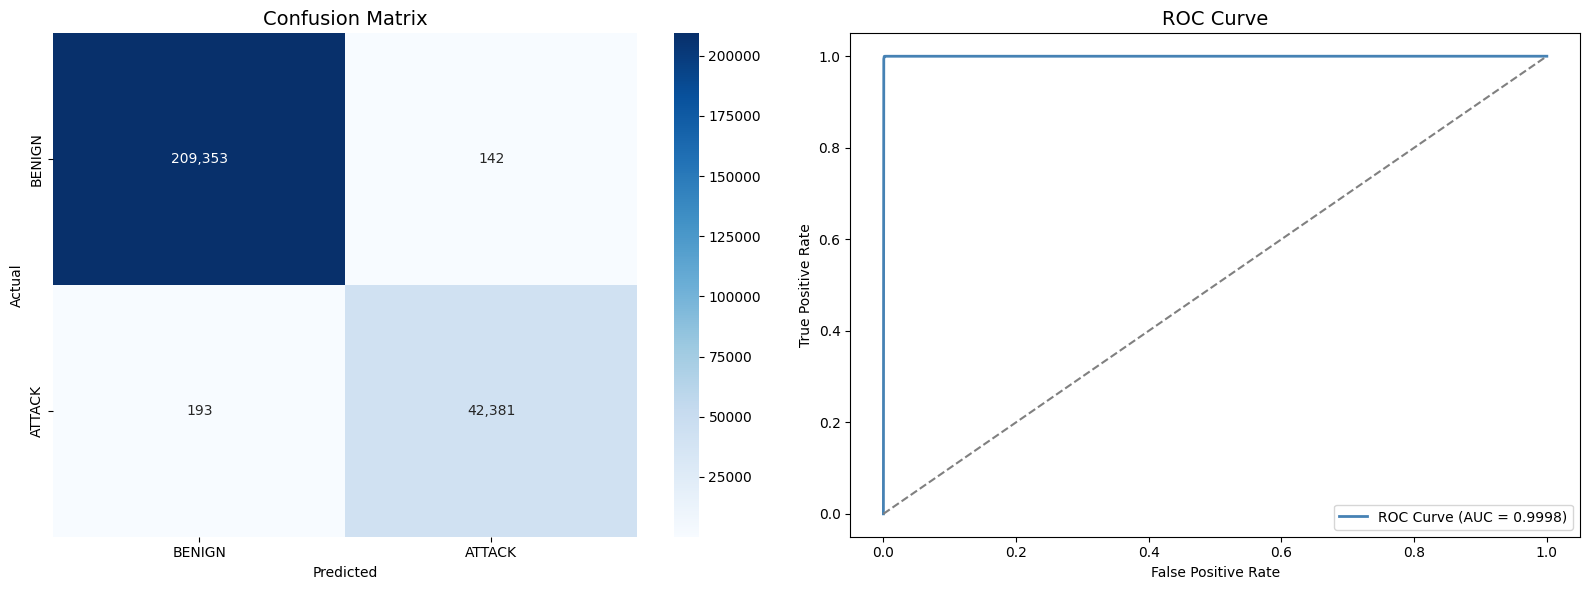


=== Top 15 Most Important Features ===


/tmp/ipykernel_8258/2875509865.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


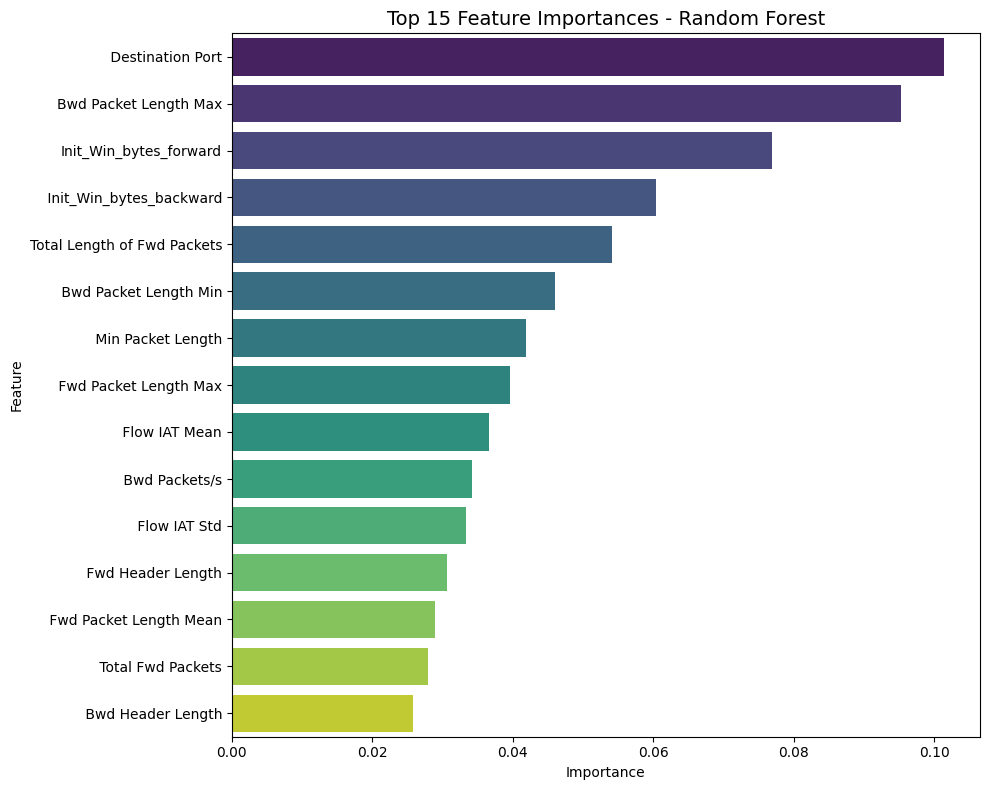

                    Feature  Importance
           Destination Port    0.101434
      Bwd Packet Length Max    0.095245
     Init_Win_bytes_forward    0.076905
    Init_Win_bytes_backward    0.060345
Total Length of Fwd Packets    0.054118
      Bwd Packet Length Min    0.046020
          Min Packet Length    0.041916
      Fwd Packet Length Max    0.039552
              Flow IAT Mean    0.036560
              Bwd Packets/s    0.034133
               Flow IAT Std    0.033388
          Fwd Header Length    0.030617
     Fwd Packet Length Mean    0.028954
          Total Fwd Packets    0.027914
          Bwd Header Length    0.025810


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# ===== PREDICTIONS =====
print("Generating predictions...")
y_pred = rf_model.predict(X_val_scaled)
y_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]

# ===== CLASSIFICATION REPORT =====
print("\n=== Random Forest - Classification Report ===\n")
print(classification_report(y_val_binary, y_pred,
                            target_names=['BENIGN', 'ATTACK']))

# ===== ROC-AUC =====
auc_score = roc_auc_score(y_val_binary, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

# ===== PLOTS =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_val_binary, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_val_binary, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/rf_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ===== FEATURE IMPORTANCE =====
print("\n=== Top 15 Most Important Features ===")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/rf_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(feature_importance.to_string(index=False))

In [40]:
from xgboost import XGBClassifier
import time

# Calculate scale_pos_weight (ratio of BENIGN to ATTACK)
scale_pos_weight = y_train_binary.value_counts()[0] / y_train_binary.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost
print("\nTraining XGBoost...")
start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handle imbalanced data
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=1
)

xgb_model.fit(
    X_train_scaled, y_train_binary,
    eval_set=[(X_val_scaled, y_val_binary)],
    verbose=10  # Print every 10 trees
)

train_time = time.time() - start_time
print(f"\n✅ Training completed in {train_time/60:.1f} minutes!")

# Save to Drive
joblib.dump(xgb_model, '/content/drive/MyDrive/CICIDS2017_Project/xgb_model.pkl')
print("✅ Model saved to Drive!")

scale_pos_weight: 4.92

Training XGBoost...
[0]	validation_0-auc:0.98925
[10]	validation_0-auc:0.99877
[20]	validation_0-auc:0.99956
[30]	validation_0-auc:0.99975
[40]	validation_0-auc:0.99984
[50]	validation_0-auc:0.99987
[60]	validation_0-auc:0.99990
[70]	validation_0-auc:0.99991
[80]	validation_0-auc:0.99993
[90]	validation_0-auc:0.99994
[99]	validation_0-auc:0.99995

✅ Training completed in 0.3 minutes!
✅ Model saved to Drive!


=== XGBoost - Validation Results ===

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    209495
      ATTACK       0.99      1.00      1.00     42574

    accuracy                           1.00    252069
   macro avg       1.00      1.00      1.00    252069
weighted avg       1.00      1.00      1.00    252069

ROC-AUC Score: 0.9999


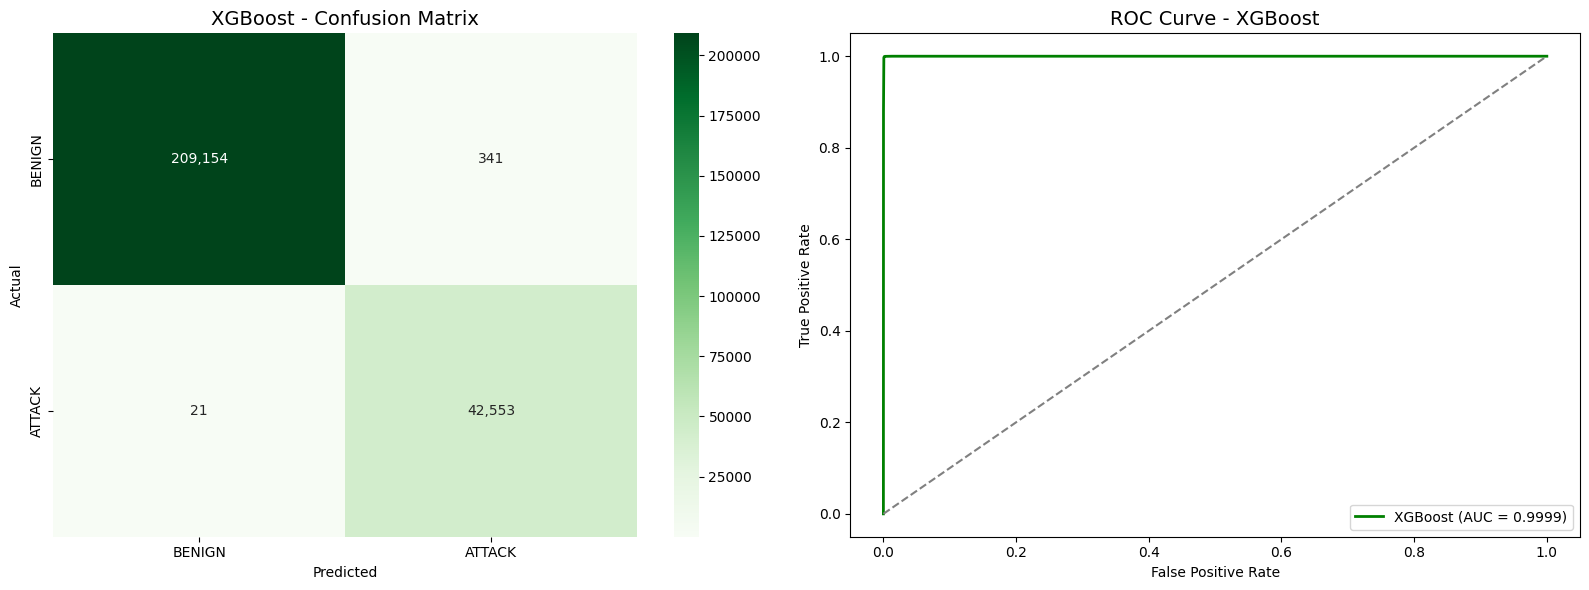

In [41]:
# Evaluate XGBoost
print("=== XGBoost - Validation Results ===\n")

y_pred_xgb = xgb_model.predict(X_val_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]

print(classification_report(y_val_binary, y_pred_xgb,
                            target_names=['BENIGN', 'ATTACK']))

auc_score_xgb = roc_auc_score(y_val_binary, y_pred_proba_xgb)
print(f"ROC-AUC Score: {auc_score_xgb:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_xgb = confusion_matrix(y_val_binary, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Greens',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            ax=axes[0])
axes[0].set_title('XGBoost - Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_val_binary, y_pred_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='green', lw=2,
             label=f'XGBoost (AUC = {auc_score_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - XGBoost', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/xgb_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [42]:
from sklearn.linear_model import LogisticRegression
import time

# Train Logistic Regression
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',  # Handle imbalanced data
    random_state=42,
    max_iter=1000,            # More iterations to converge
    n_jobs=-1
)

lr_model.fit(X_train_scaled, y_train_binary)

train_time = time.time() - start_time
print(f"✅ Training completed in {train_time/60:.1f} minutes!")

# Save to Drive
joblib.dump(lr_model, '/content/drive/MyDrive/CICIDS2017_Project/lr_model.pkl')
print("✅ Model saved to Drive!")

Training Logistic Regression...
✅ Training completed in 0.9 minutes!
✅ Model saved to Drive!


=== Logistic Regression - Validation Results ===

              precision    recall  f1-score   support

      BENIGN       0.99      0.89      0.94    209495
      ATTACK       0.64      0.96      0.77     42574

    accuracy                           0.90    252069
   macro avg       0.82      0.93      0.85    252069
weighted avg       0.93      0.90      0.91    252069

ROC-AUC Score: 0.9789


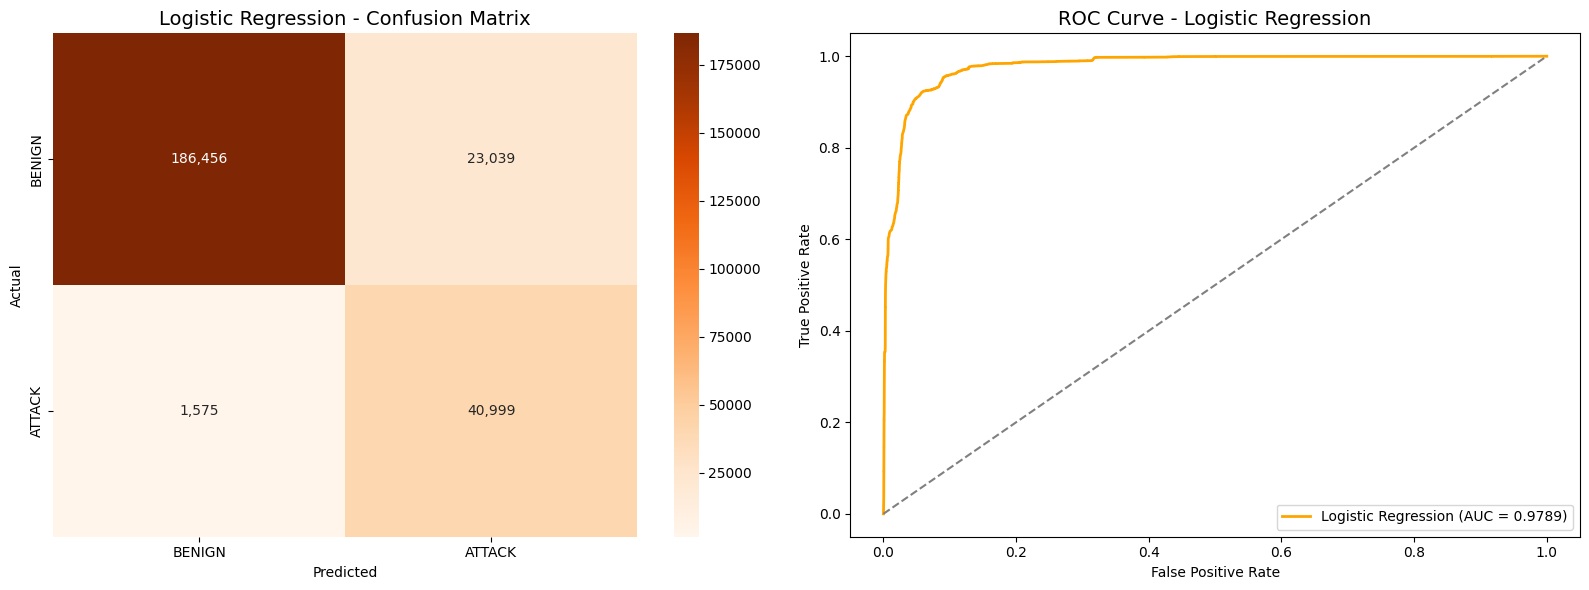

In [43]:
# Evaluate Logistic Regression
print("=== Logistic Regression - Validation Results ===\n")

y_pred_lr = lr_model.predict(X_val_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

print(classification_report(y_val_binary, y_pred_lr,
                            target_names=['BENIGN', 'ATTACK']))

auc_score_lr = roc_auc_score(y_val_binary, y_pred_proba_lr)
print(f"ROC-AUC Score: {auc_score_lr:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lr = confusion_matrix(y_val_binary, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt=',', cmap='Oranges',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_val_binary, y_pred_proba_lr)
axes[1].plot(fpr_lr, tpr_lr, color='orange', lw=2,
             label=f'Logistic Regression (AUC = {auc_score_lr:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/lr_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

=== FINAL TEST SET EVALUATION - XGBoost ===

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    209495
      ATTACK       0.99      1.00      1.00     42574

    accuracy                           1.00    252069
   macro avg       1.00      1.00      1.00    252069
weighted avg       1.00      1.00      1.00    252069

ROC-AUC Score: 0.9999


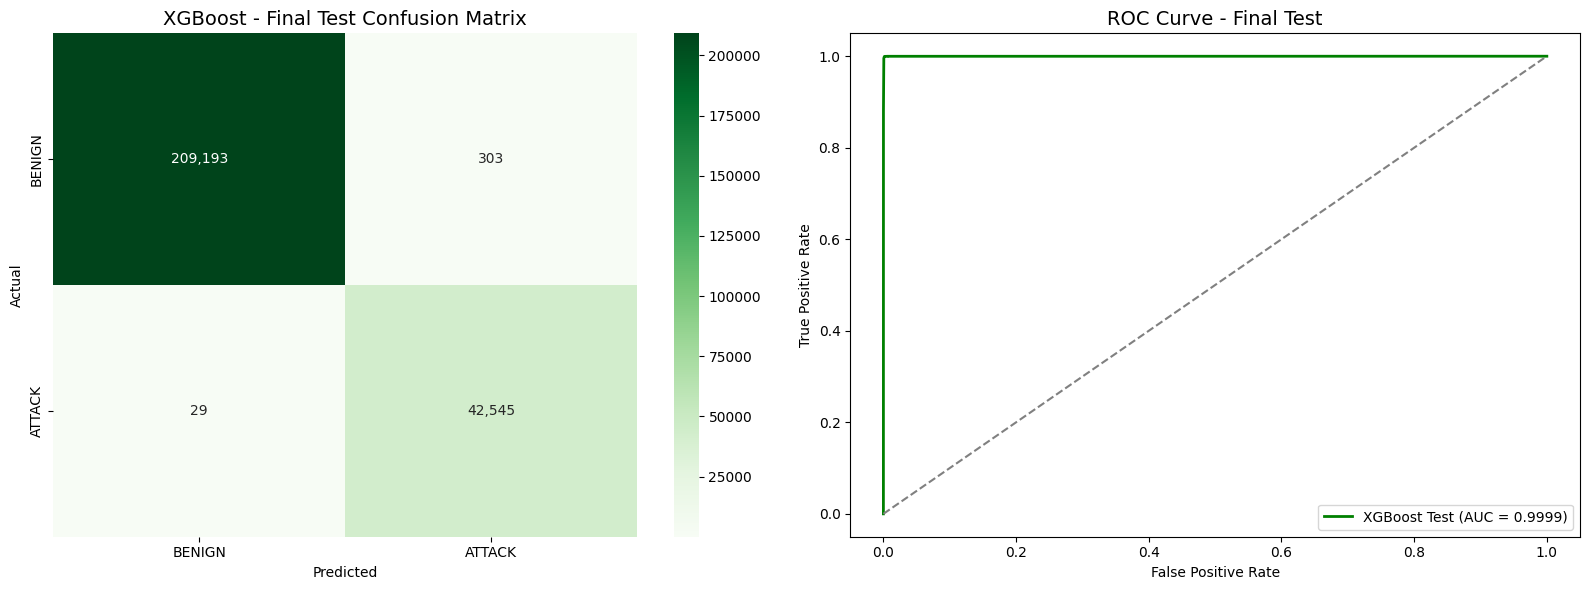

✅ Final evaluation complete!


In [44]:
# Final Evaluation on Test set - XGBoost
print("=== FINAL TEST SET EVALUATION - XGBoost ===\n")

y_pred_test = xgb_model.predict(X_test_scaled)
y_pred_proba_test = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_val_binary, y_pred_xgb,
                            target_names=['BENIGN', 'ATTACK']))

auc_score_test = roc_auc_score(y_test_binary, y_pred_proba_test)
print(f"ROC-AUC Score: {auc_score_test:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_test = confusion_matrix(y_test_binary, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt=',', cmap='Greens',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            ax=axes[0])
axes[0].set_title('XGBoost - Final Test Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr_test, tpr_test, _ = roc_curve(y_test_binary, y_pred_proba_test)
axes[1].plot(fpr_test, tpr_test, color='green', lw=2,
             label=f'XGBoost Test (AUC = {auc_score_test:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Final Test', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/xgb_final_test.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final evaluation complete!")

In [45]:
# Multi-class Classification with XGBoost
print("Training XGBoost - Multi-class...")
start_time = time.time()

xgb_multi = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    objective='multi:softprob',  # Multi-class mode
    num_class=15,                # 15 attack types
    eval_metric='mlogloss',
    verbosity=1
)

xgb_multi.fit(
    X_train_scaled, y_train_multi,
    eval_set=[(X_val_scaled, y_val_multi)],
    verbose=10
)

train_time = time.time() - start_time
print(f"\n✅ Training completed in {train_time/60:.1f} minutes!")

# Save to Drive
joblib.dump(xgb_multi, '/content/drive/MyDrive/CICIDS2017_Project/xgb_multi_model.pkl')
print("✅ Model saved to Drive!")

Training XGBoost - Multi-class...
[0]	validation_0-mlogloss:0.44744
[10]	validation_0-mlogloss:0.12945
[20]	validation_0-mlogloss:0.05039
[30]	validation_0-mlogloss:0.02297
[40]	validation_0-mlogloss:0.01239
[50]	validation_0-mlogloss:0.00809
[60]	validation_0-mlogloss:0.00600
[70]	validation_0-mlogloss:0.00503
[80]	validation_0-mlogloss:0.00452
[90]	validation_0-mlogloss:0.00422
[99]	validation_0-mlogloss:0.00407

✅ Training completed in 3.2 minutes!
✅ Model saved to Drive!


=== XGBoost Multi-class - Validation Results ===

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    209495
                       Bot       0.96      0.75      0.84       194
                      DDoS       1.00      1.00      1.00     12870
             DoS GoldenEye       1.00      0.99      1.00      1000
                  DoS Hulk       1.00      1.00      1.00     17307
          DoS Slowhttptest       0.98      0.99      0.99       496
             DoS slowloris       0.99      1.00      1.00       542
               FTP-Patator       1.00      1.00      1.00       543
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      0.50      0.67         4
                  PortScan       0.99      1.00      0.99      9077
               SSH-Patator       1.00      1.00      1.00       338
  Web Attack � Brute Force       0.71      0.89      0.79       1

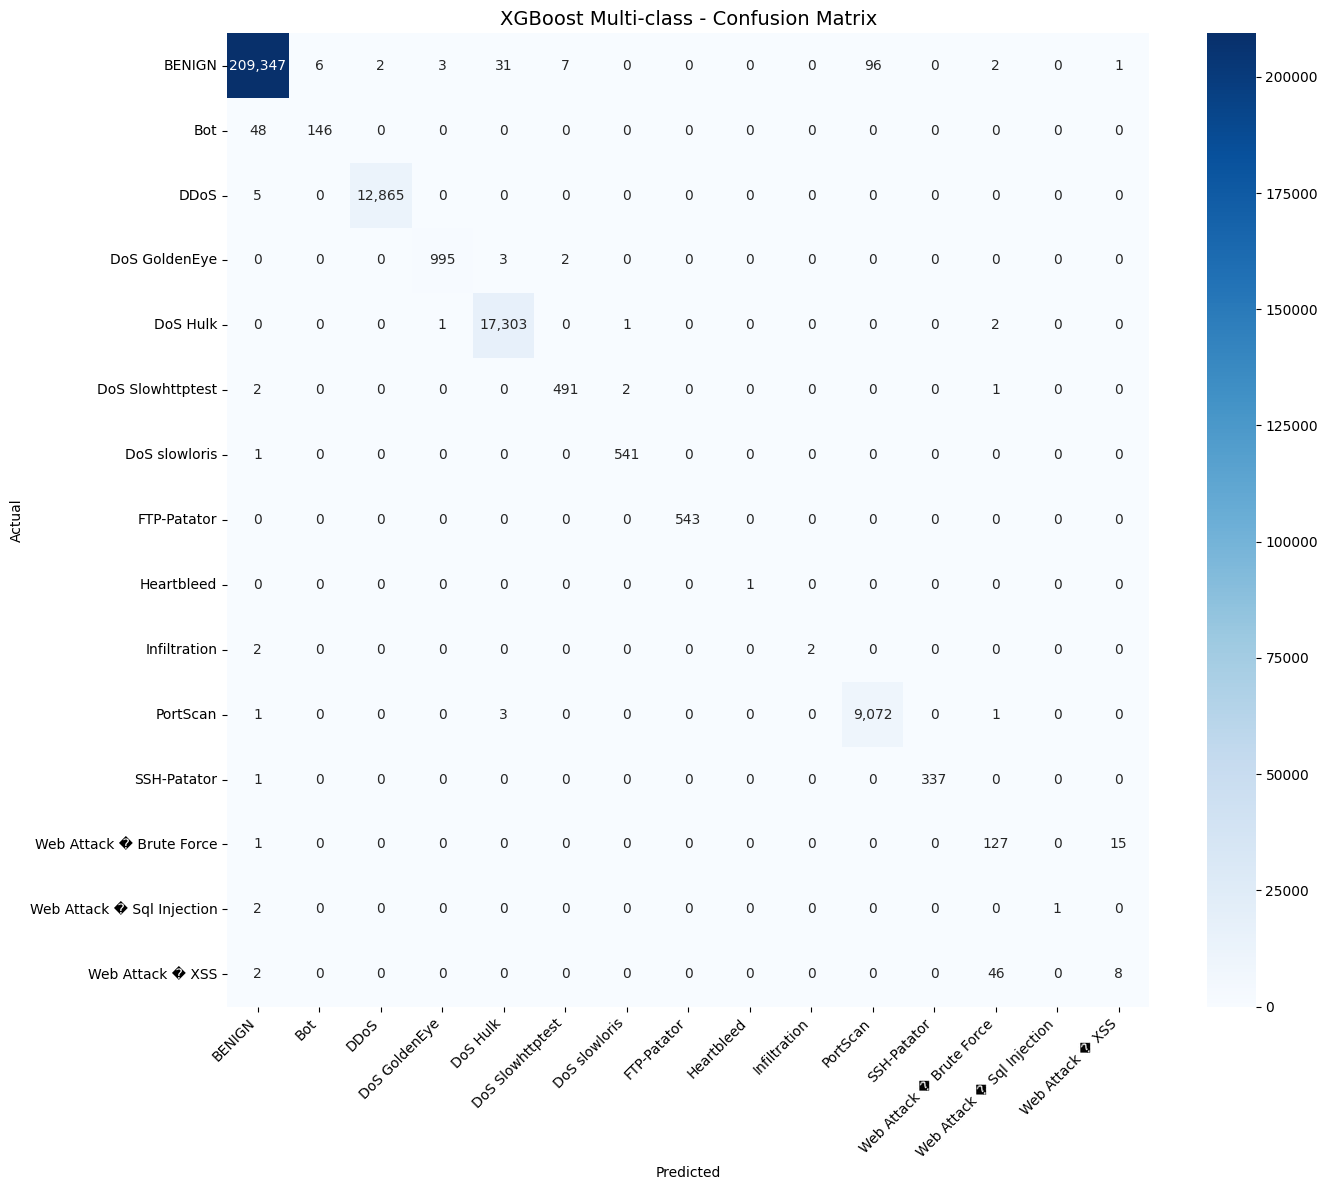

In [46]:
# Evaluate Multi-class
print("=== XGBoost Multi-class - Validation Results ===\n")

y_pred_multi = xgb_multi.predict(X_val_scaled)

# Get label names
label_names = le.classes_

print(classification_report(y_val_multi, y_pred_multi,
                            target_names=label_names))

# Confusion Matrix
plt.figure(figsize=(14, 12))
cm_multi = confusion_matrix(y_val_multi, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt=',', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('XGBoost Multi-class - Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/xgb_multiclass.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [47]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("Starting Randomized Search...")
print("Testing 10 random combinations...\n")

xgb_tuned = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

random_search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_grid,
    n_iter=10,           # Reduced to 10 combinations
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_scaled, y_train_binary)

print(f"\n✅ Best parameters found:")
print(random_search.best_params_)
print(f"\nBest F1 Score: {random_search.best_score_:.4f}")

# Save results to Drive
joblib.dump(random_search, '/content/drive/MyDrive/CICIDS2017_Project/random_search_results.pkl')
print("✅ Saved to Drive!")

Starting Randomized Search...
Testing 10 random combinations...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best parameters found:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 0.8}

Best F1 Score: 0.9972
✅ Saved to Drive!


In [48]:
# Train final tuned model
print("Training Final Tuned XGBoost...")
start_time = time.time()

xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=1
)

xgb_final.fit(
    X_train_scaled, y_train_binary,
    eval_set=[(X_val_scaled, y_val_binary)],
    verbose=10
)

train_time = time.time() - start_time
print(f"\n✅ Training completed in {train_time/60:.1f} minutes!")

# Save to Drive
joblib.dump(xgb_final, '/content/drive/MyDrive/CICIDS2017_Project/xgb_final_tuned.pkl')
print("✅ Final model saved to Drive!")

Training Final Tuned XGBoost...
[0]	validation_0-auc:0.98622
[10]	validation_0-auc:0.99981
[20]	validation_0-auc:0.99991
[30]	validation_0-auc:0.99994
[40]	validation_0-auc:0.99996
[50]	validation_0-auc:0.99997
[60]	validation_0-auc:0.99997
[70]	validation_0-auc:0.99998
[80]	validation_0-auc:0.99998
[90]	validation_0-auc:0.99998
[100]	validation_0-auc:0.99998
[110]	validation_0-auc:0.99998
[120]	validation_0-auc:0.99998
[130]	validation_0-auc:0.99998
[140]	validation_0-auc:0.99998
[150]	validation_0-auc:0.99998
[160]	validation_0-auc:0.99998
[170]	validation_0-auc:0.99998
[180]	validation_0-auc:0.99998
[190]	validation_0-auc:0.99998
[199]	validation_0-auc:0.99998

✅ Training completed in 0.5 minutes!
✅ Final model saved to Drive!


=== Final Tuned XGBoost - Test Set Evaluation ===

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    209496
      ATTACK       1.00      1.00      1.00     42574

    accuracy                           1.00    252070
   macro avg       1.00      1.00      1.00    252070
weighted avg       1.00      1.00      1.00    252070

ROC-AUC Score: 1.0000


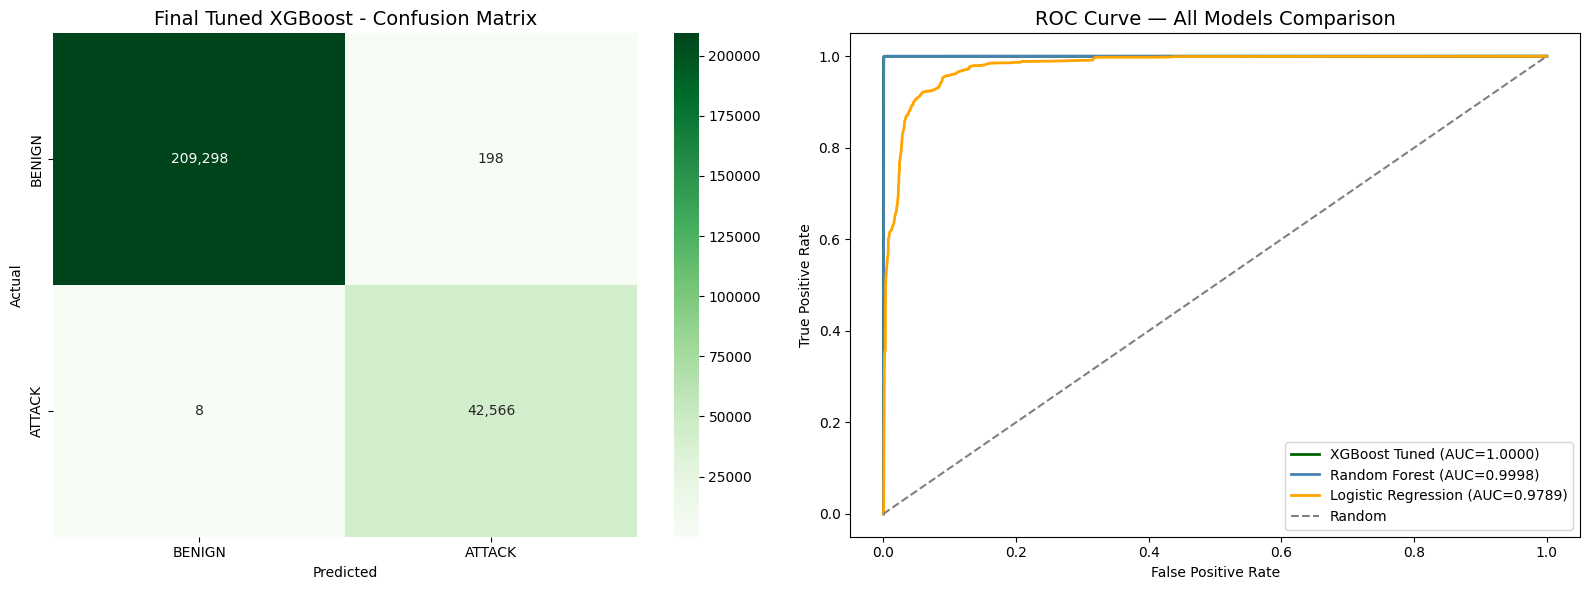

✅ Final evaluation complete!


In [49]:
# Final evaluation of tuned model
print("=== Final Tuned XGBoost - Test Set Evaluation ===\n")

y_pred_final = xgb_final.predict(X_test_scaled)
y_pred_proba_final = xgb_final.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test_binary, y_pred_final,
                            target_names=['BENIGN', 'ATTACK']))

auc_final = roc_auc_score(y_test_binary, y_pred_proba_final)
print(f"ROC-AUC Score: {auc_final:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_final = confusion_matrix(y_test_binary, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt=',', cmap='Greens',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            ax=axes[0])
axes[0].set_title('Final Tuned XGBoost - Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve — השוואה של כל המודלים
fpr_final, tpr_final, _ = roc_curve(y_test_binary, y_pred_proba_final)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, rf_model.predict_proba(X_test_scaled)[:, 1])
fpr_lr, tpr_lr, _ = roc_curve(y_test_binary, lr_model.predict_proba(X_test_scaled)[:, 1])

axes[1].plot(fpr_final, tpr_final, color='darkgreen', lw=2, label=f'XGBoost Tuned (AUC={auc_final:.4f})')
axes[1].plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest (AUC=0.9998)')
axes[1].plot(fpr_lr, tpr_lr, color='orange', lw=2, label=f'Logistic Regression (AUC=0.9789)')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — All Models Comparison', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS2017_Project/final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final evaluation complete!")